# DSCI 552 - Homework 2

- **Name:** Jesse Fulcher
- **GitHub Username:** jfulch
- **USC ID:** 7451-9585-45

## 1(a) - Combined Cycle Power Plant Data Set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

power_plant_data = pd.read_excel(
    "../data/Folds5x2_pp.xlsx",
    sheet_name="Sheet1"
)

print("Shape:", power_plant_data.shape)
print("Columns:", power_plant_data.columns)

power_plant_data.head()

Shape: (9568, 5)
Columns: Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) - Exploring the Data

### 1(b)(i) - Dataset Dimensions

In [ ]:
number_of_rows, number_of_columns = power_plant_data.shape

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)
print("Columns:", power_plant_data.columns.tolist())

Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


**Answers:** The dataset has 9,568 observations and 5 variables. Each row represents one hourly measurement taken while the power plant was operating at full load.

The variables are:

- AT: ambient temperature  
- V: exhaust vacuum  
- AP: ambient pressure  
- RH: relative humidity  
- PE: net hourly electrical energy output  

AT, V, AP, and RH are the predictor variables. PE is the response variable that the regression models will try to predict.

## 1(b)(ii) - Pairwise Scatterplots

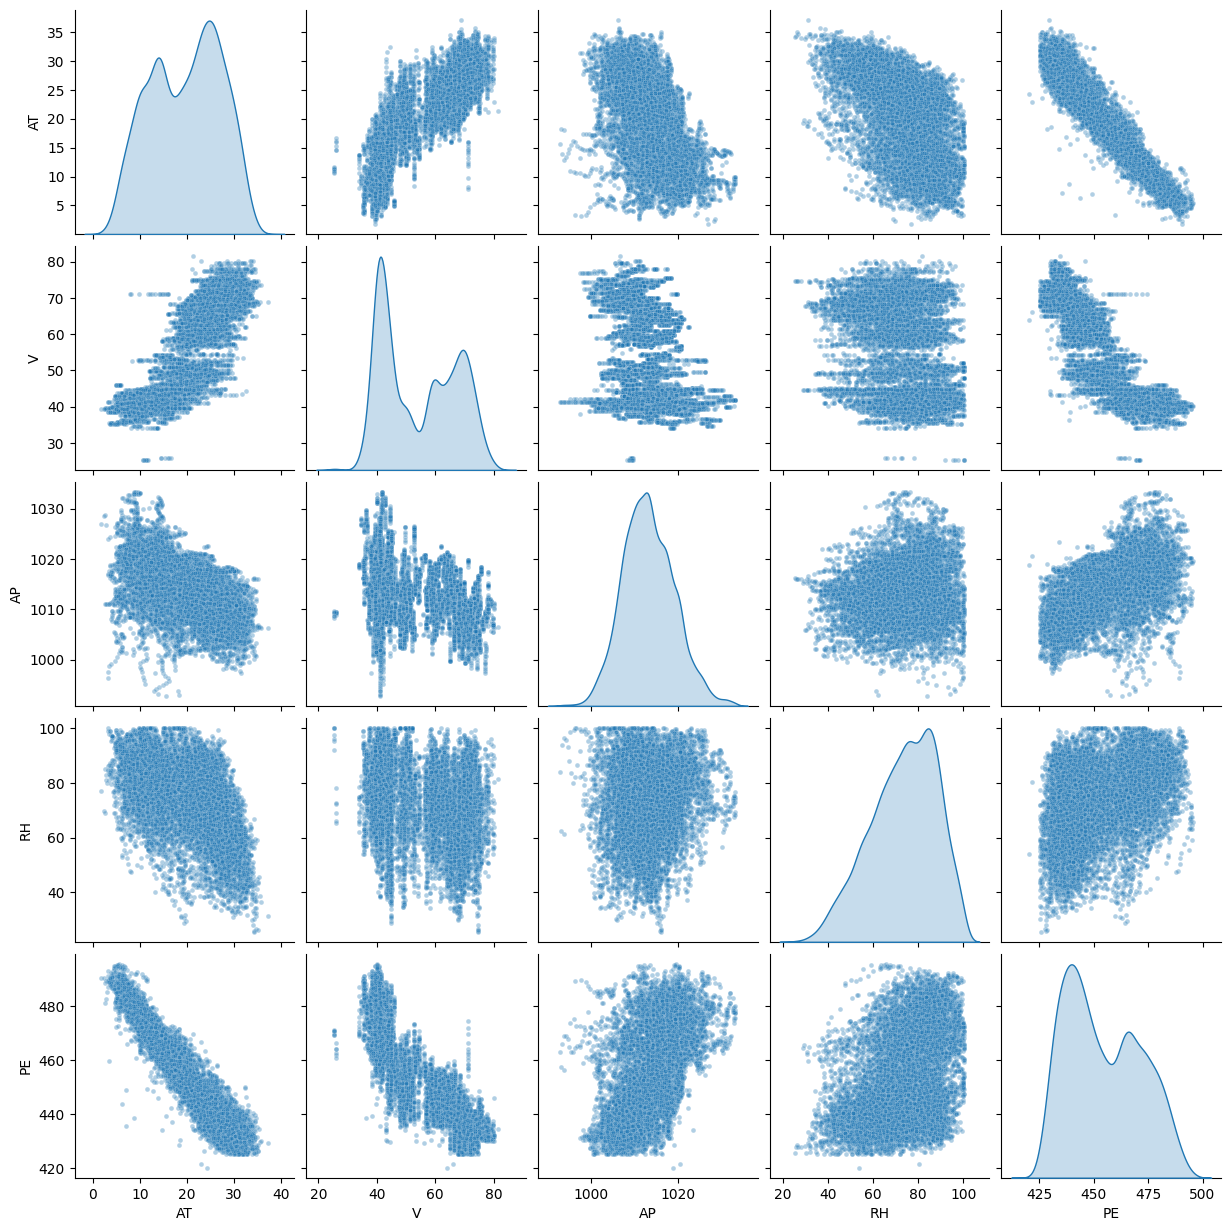

In [ ]:
pairplot = sns.pairplot(
    power_plant_data,
    vars=["AT", "V", "AP", "RH", "PE"],
    diag_kind="kde",
    plot_kws={"alpha": 0.35, "s": 12}
)

plt.show()

In [ ]:
power_plant_data.corr().round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


**Findings:** The scatterplots show that AT and V have the clearest relationships with PE. Both have negative trends, meaning that higher ambient temperature or exhaust vacuum is generally associated with lower electrical energy output. The relationship between AT and PE appears to be the strongest and is close to linear.

AP and RH show weaker positive relationships with PE. Their plots have more spread around the overall trend, so they do not appear to be as strong on their own as AT or V for predicting energy output.

### 1(b)(iii) - Summary Statistics

In [ ]:
summary_statistics = power_plant_data.aggregate([
    "mean",
    "median",
    "min",
    "max",
    lambda column: column.quantile(0.25),
    lambda column: column.quantile(0.75)
])

summary_statistics.index = [
    "Mean", 
    "Median", 
    "Minimum", 
    "Maximum",
    "First Quartile",
    "Third Quartile"
]

summary_statistics.loc["Range"] = (
    summary_statistics.loc["Maximum"] - summary_statistics.loc["Minimum"]
)

summary_statistics.loc["Interquartile Range"] = (
    summary_statistics.loc["Third Quartile"] - summary_statistics.loc["First Quartile"]
)

summary_statistics = summary_statistics.loc[
    [
        "Mean",
        "Median",
        "Minimum",
        "Maximum",
        "First Quartile",
        "Third Quartile",
        "Range",
        "Interquartile Range"
    ]
]

summary_statistics.round(2)

,AT,V,AP,RH,PE
Mean,19.65,54.31,1013.26,73.31,454.37
Median,20.34,52.08,1012.94,74.97,451.55
Minimum,1.81,25.36,992.89,25.56,420.26
Maximum,37.11,81.56,1033.30,100.16,495.76
First Quartile,13.51,41.74,1009.10,63.33,439.75
Third Quartile,25.72,66.54,1017.26,84.83,468.43
Range,35.30,56.20,40.41,74.60,75.50
Interquartile Range,12.21,24.80,8.16,21.50,28.68


## 1(c) - Simple Linear Regression

In [ ]:
pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]
simple_models ={}
simple_regression_results =[]

for predictor in predictors:
    x = sm.add_constant(power_plant_data[predictor])
    y = power_plant_data["PE"]

    model = sm.OLS(y, x).fit()
    simple_models[predictor] = model

    simple_regression_results.append(
        {"Predictor": predictor,
         "Intercept": model.params["const"],
         "Coefficient": model.params[predictor],
         "Standard Error": model.bse[predictor],
         "p-value": model.pvalues[predictor],
         "R-squared": model.rsquared
    })

simple_regression_table = pd.DataFrame(simple_regression_results)
simple_regression_table


,Predictor,Intercept,Coefficient,Standard Error,p-value,R-squared
0,AT,497.034120,-2.171320,0.007443,0.0,0.898948
1,V,517.801526,-1.168135,0.006776,0.0,0.756518
2,AP,-1055.260989,1.489872,0.025126,0.0,0.268769
3,RH,420.961766,0.455650,0.011006,0.0,0.151939


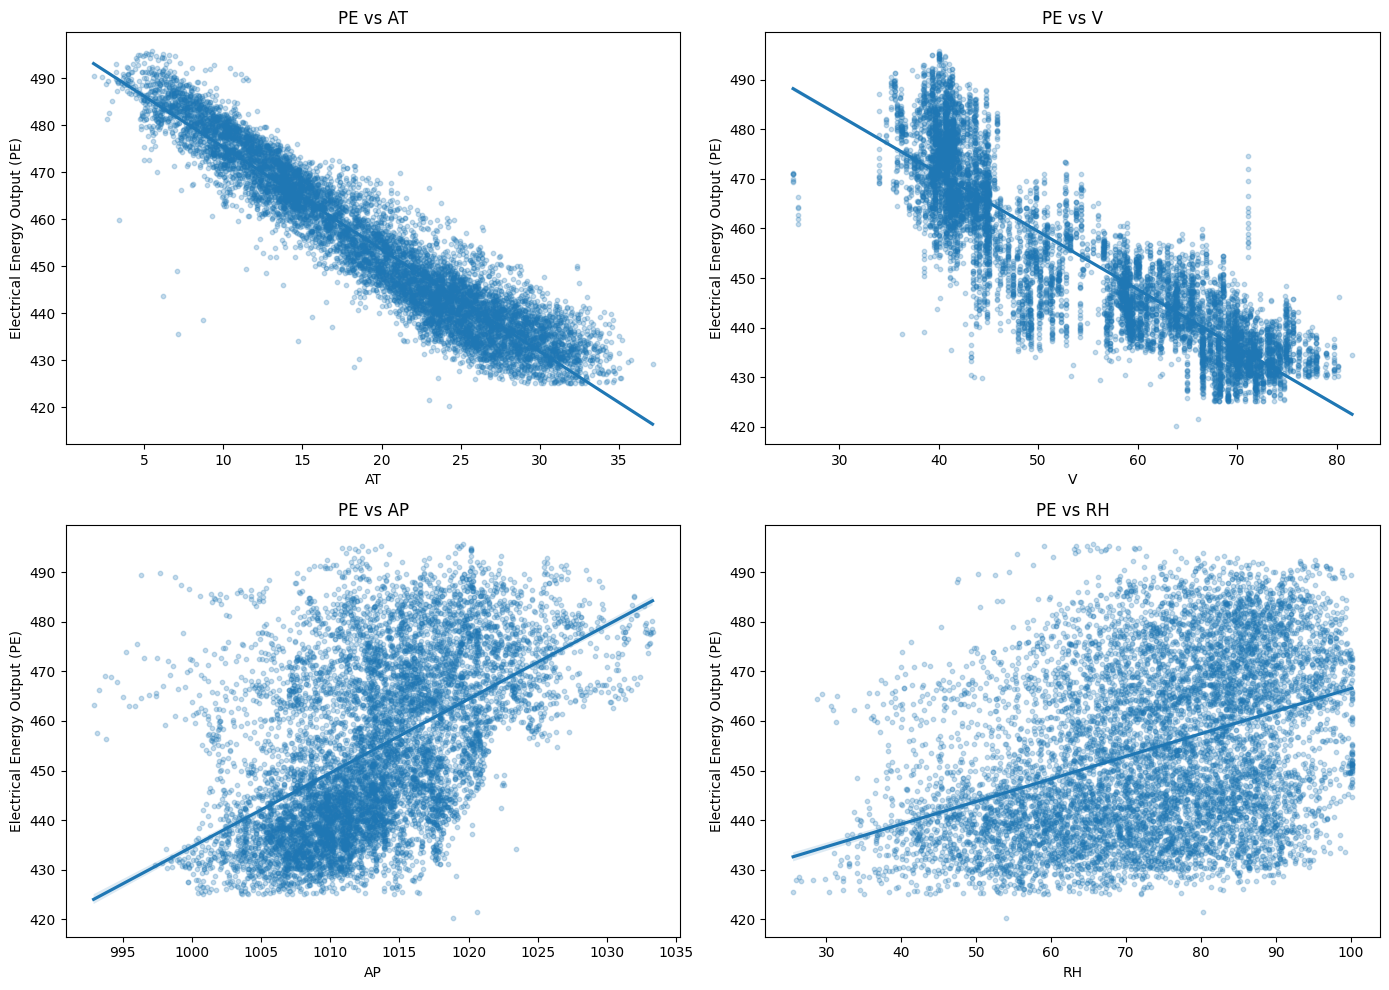

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for predictor, axis in zip(predictors, axes.flatten()):
    sns.regplot(
        data=power_plant_data,
        x=predictor,
        y="PE",
        ax=axis,
        scatter_kws={"alpha": .25, "s": 10}
    )

    axis.set_title(f"PE vs {predictor}")
    axis.set_ylabel("Electrical Energy Output (PE)")
    axis.set_xlabel(predictor)
    
plt.tight_layout()
plt.show()

In [ ]:
outlier_results = []
diagnostic_data = {}

for predictor, model in simple_models.items():
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]

    diagnostic_data[predictor] = {
        "fitted": model.fittedvalues,
        "studentized_residuals": studentized_residuals,
        "cooks_distance": cooks_distance
    }

    outlier_results.append({
        "Predictor": predictor,
        "|Studentized residual| > 3": (
            np.abs(studentized_residuals) > 3
        ).sum(),
        "Cook's distance > 4/n": (
            cooks_distance > 4 / len(power_plant_data)
        ).sum(),
        "Cook's distance > 1": (cooks_distance > 1).sum(),
        "Maximum Cook's distance": cooks_distance.max(),
    })

outlier_summary = pd.DataFrame(outlier_results)
outlier_summary

,Predictor,|Studentized residual| > 3,Cook's distance > 4/n,Cook's distance > 1,Maximum Cook's distance
0,AT,42,416,0,0.014325
1,V,33,423,0,0.003243
2,AP,30,300,0,0.008152
3,RH,2,249,0,0.002059


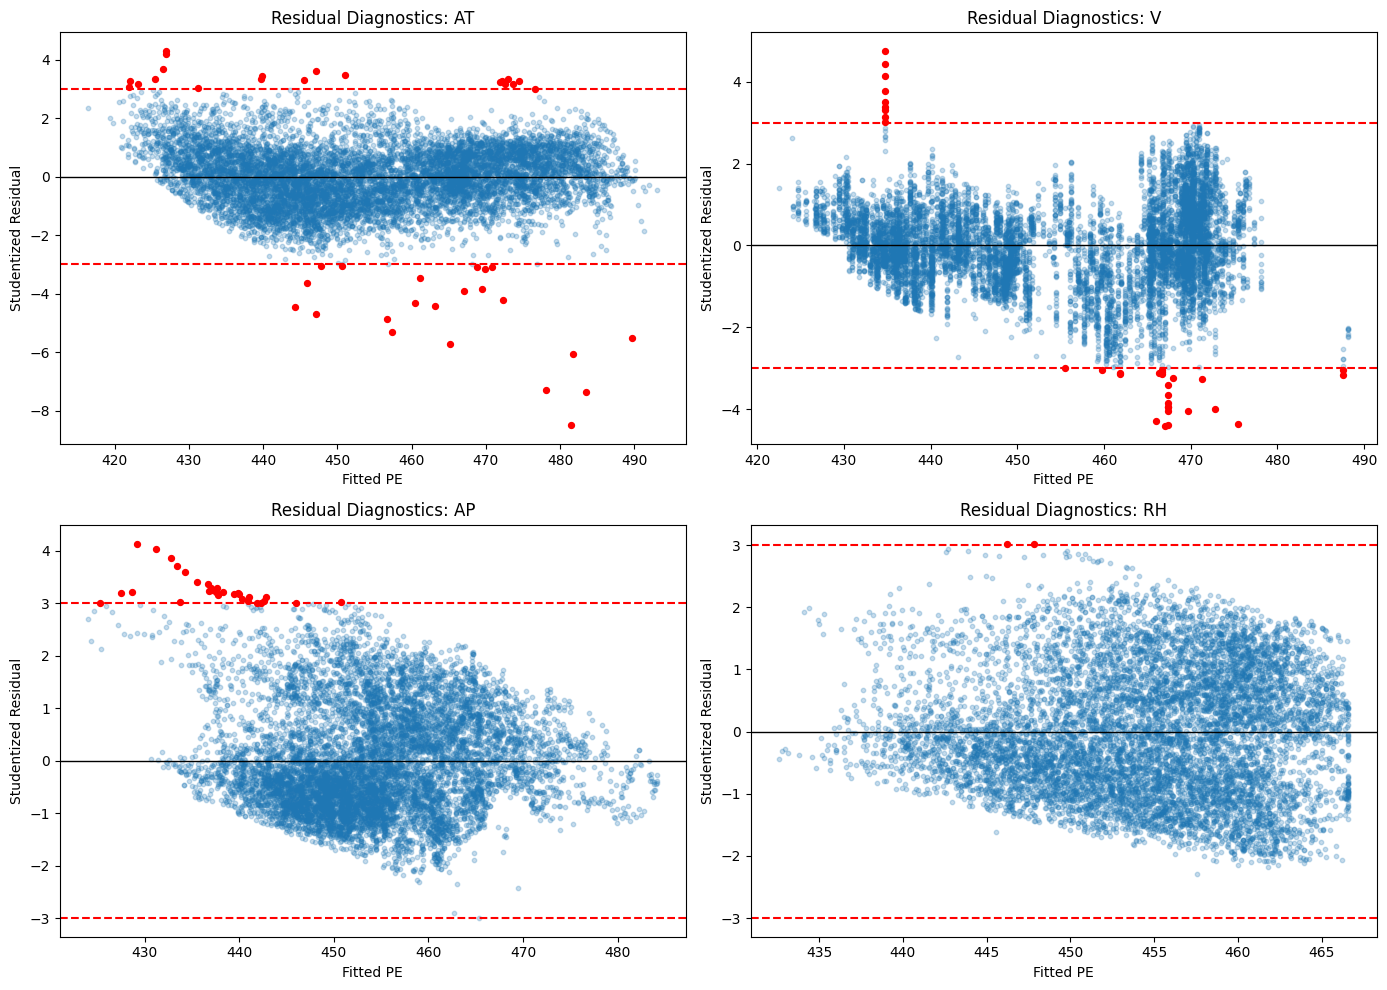

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for predictor, axis in zip(predictors, axes.flatten()):
    diagnostics = diagnostic_data[predictor]
    residuals = diagnostics["studentized_residuals"]
    unusual = np.abs(residuals) > 3

    axis.scatter(
        diagnostics["fitted"],
        residuals,
        alpha=0.25,
        s=10,
        label="Observations",
    )
    axis.scatter(
        diagnostics["fitted"][unusual],
        residuals[unusual],
        color="red",
        s=18,
        label="|Studentized residual| > 3",
    )

    axis.axhline(0, color="black", linewidth=1)
    axis.axhline(3, color="red", linestyle="--")
    axis.axhline(-3, color="red", linestyle="--")
    axis.set_title(f"Residual Diagnostics: {predictor}")
    axis.set_xlabel("Fitted PE")
    axis.set_ylabel("Studentized Residual")

plt.tight_layout()
plt.show()

**Answer**: All four predictors are statistically significant in their individual regression models, since each slope has a p-value below 0.001.

AT has the strongest individual relationship with PE. Its coefficient is \(-2.1713\), so a one-unit increase in ambient temperature is associated with about a 2.17-unit decrease in predicted energy output. The model using only AT has an \(R^2\) of 0.8989, meaning it explains about 89.89% of the variation in PE.

V also has a strong negative relationship with PE, with a coefficient of \(-1.1681\) and an \(R^2\) of 0.7565. AP and RH have positive coefficients of 1.4899 and 0.4557. However, their individual \(R^2\) values are lower: 0.2688 for AP and 0.1519 for RH. This means they are weaker predictors of PE when considered by themselves.

The residual plots show a few observations with large studentized residuals. However, none of the points has a Cook's distance above 1 in any of the models, so there is no strong reason to remove observations automatically. I would only remove a point if there were evidence that it was caused by a measurement or data-entry error.

## 1(d) - Multiple Linear Regression

In [ ]:
multiple_x = power_plant_data[["AT", "V", "AP", "RH"]]
multiple_x = sm.add_constant(multiple_x)

y = power_plant_data["PE"]

multiple_model = sm.OLS(y, multiple_x).fit()

multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:37:44   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Answer:** The multiple regression model has an \(R^2\) of 0.9287, so AT, V, AP, and RH together explain about 92.87% of the variation in PE.

All four predictors have p-values below 0.05, so they are statistically significant in the full model. This means that each variable is still related to PE even after accounting for the other three predictors.

Keeping the other variables constant, a one-unit increase in AT is associated with about a 1.98-unit decrease in predicted PE. A one-unit increase in V is associated with about a 0.23-unit decrease in PE. AP has a small positive coefficient: a one-unit increase in AP is associated with about a 0.06-unit increase in PE. RH has a negative coefficient, meaning a one-unit increase in RH is associated with about a 0.16-unit decrease in predicted PE.

## 1(e) - Comparison of Simple and Multiple Regression Coefficients

In [ ]:
coefficient_comparison = pd.DataFrame({
    "Predictor": predictors,
    "Simple Regression": [
        simple_models[predictor].params[predictor]
        for predictor in predictors
    ],
    "Multiple Regression": [
        multiple_model.params[predictor]
        for predictor in predictors
    ]
})

coefficient_comparison

,Predictor,Simple Regression,Multiple Regression
0,AT,-2.171320,-1.977513
1,V,-1.168135,-0.233916
2,AP,1.489872,0.062083
3,RH,0.455650,-0.158054


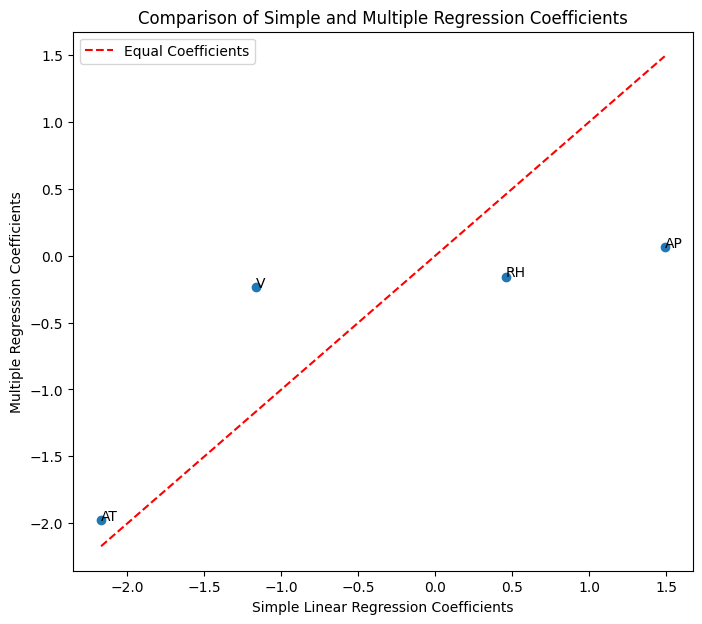

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
)

for _, row in coefficient_comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (
            row["Simple Regression"],
            row["Multiple Regression"],
        )
    )

minimum_coefficient = min(
    coefficient_comparison["Simple Regression"].min(),
    coefficient_comparison["Multiple Regression"].min(),
)

maximum_coefficient = max(
    coefficient_comparison["Simple Regression"].max(),
    coefficient_comparison["Multiple Regression"].max(),
)
plt.plot(
    [minimum_coefficient, maximum_coefficient],
    [minimum_coefficient, maximum_coefficient],
    color="red",
    linestyle="--",
    label="Equal Coefficients"
)

plt.xlabel("Simple Linear Regression Coefficients")
plt.ylabel("Multiple Regression Coefficients")
plt.title("Comparison of Simple and Multiple Regression Coefficients")
plt.legend()
plt.show()


**Answer:** All four predictors are statistically significant in both the simple regression models and the full multiple regression model. However, several coefficients change once the other predictors are included.

The coefficient for AT changes only slightly, from \(-2.1713\) in the simple regression to \(-1.9775\) in the multiple regression. It remains strongly negative in both models.

The coefficients for V and AP change much more. The coefficient for V goes from \(-1.1681\) to \(-0.2339\), while the coefficient for AP goes from \(1.4899\) to \(0.0621\). Both are still significant, but their smaller coefficients in the full model suggest that some of the relationship they had with PE in the simple models overlaps with the other predictors.

RH changes from a positive coefficient of \(0.4557\) in the simple regression to a negative coefficient of \(-0.1581\) in the multiple regression. On its own, higher RH is associated with higher PE, but after accounting for AT, V, and AP, the relationship becomes negative.

These changes make sense because the predictors are correlated with each other. In the simple models, each variable is considered by itself. In the multiple regression model, the coefficient for each variable reflects its relationship with PE after accounting for the other predictors.

## 1(f) - Nonlinear Associations

In [ ]:
polynomial_models = {}
polynomial_results = []

for predictor in predictors:
    centered_x = (
        power_plant_data[predictor]
        - power_plant_data[predictor].mean()
    )

    polynomial_x = pd.DataFrame({
        "x": centered_x,
        "x_squared": centered_x ** 2,
        "x_cubed": centered_x ** 3,
    })

    polynomial_x = sm.add_constant(polynomial_x)
    y = power_plant_data["PE"]

    polynomial_model = sm.OLS(y, polynomial_x).fit()
    polynomial_models[predictor] = polynomial_model

    nonlinear_test = polynomial_model.f_test(
        "x_squared = 0, x_cubed = 0"
    )

    polynomial_results.append({
        "Predictor": predictor,
        "Linear p-value": polynomial_model.pvalues["x"],
        "Quadratic p-value": polynomial_model.pvalues["x_squared"],
        "Cubic p-value": polynomial_model.pvalues["x_cubed"],
        "Nonlinear joint-test p-value": float(
            nonlinear_test.pvalue
        ),
        "R-squared": polynomial_model.rsquared,
    })

polynomial_results_table = pd.DataFrame(polynomial_results)

polynomial_results_table

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,Nonlinear joint-test p-value,R-squared
0,AT,0.000000e+00,3.311808e-231,3.652185e-110,3.478379e-285,0.911883
1,V,0.000000e+00,8.977010e-131,1.373489e-02,7.040304e-165,0.775022
2,AP,0.000000e+00,2.192722e-46,2.123338e-67,4.209145e-84,0.297543
3,RH,9.648727e-152,1.013949e-01,1.440279e-05,3.799622e-05,0.153743


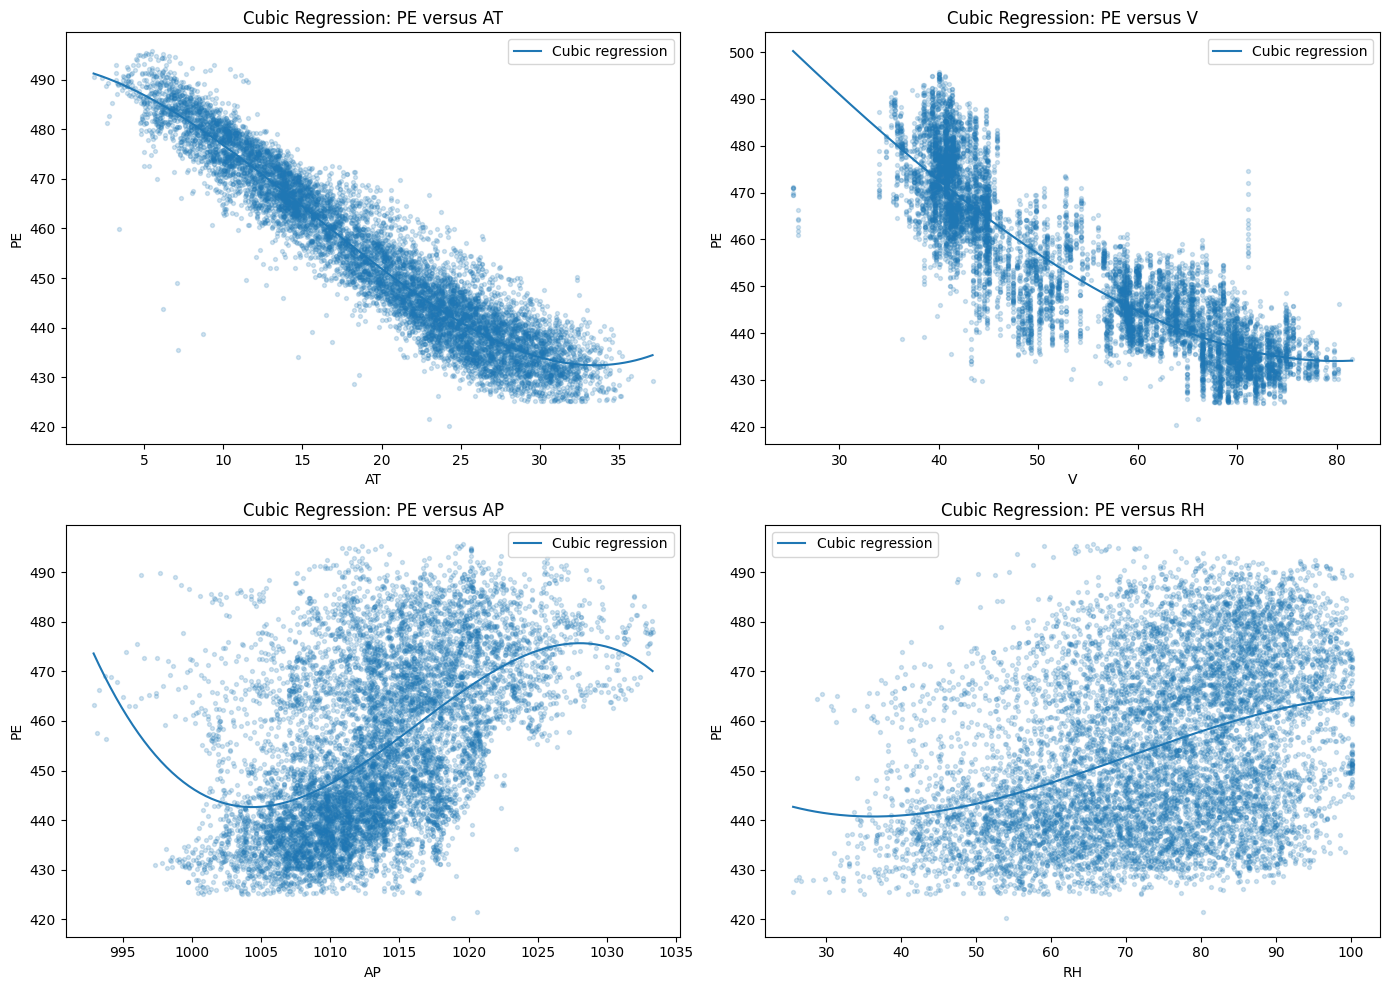

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for predictor, axis in zip(predictors, axes.flatten()):
    predictor_mean = power_plant_data[predictor].mean()

    plot_x = np.linspace(
        power_plant_data[predictor].min(),
        power_plant_data[predictor].max(),
        300,
    )

    centered_plot_x = plot_x - predictor_mean

    plot_data = pd.DataFrame({
        "const": 1.0,
        "x": centered_plot_x,
        "x_squared": centered_plot_x ** 2,
        "x_cubed": centered_plot_x ** 3,
    })

    predicted_pe = polynomial_models[predictor].predict(
        plot_data
    )

    axis.scatter(
        power_plant_data[predictor],
        power_plant_data["PE"],
        alpha=0.2,
        s=8,
    )

    axis.plot(
        plot_x,
        predicted_pe,
        label="Cubic regression",
    )

    axis.set_title(f"Cubic Regression: PE versus {predictor}")
    axis.set_xlabel(predictor)
    axis.set_ylabel("PE")
    axis.legend()

plt.tight_layout()
plt.show()

**Answer:** For each predictor, the joint test of the quadratic and cubic terms has a p-value below 0.05. This gives evidence that the relationship between each predictor and PE is not completely linear.

For AT and AP, both the quadratic and cubic terms are statistically significant. For V, the quadratic term is not significant by itself, but the cubic term and the joint test are significant. For RH, the quadratic term is not significant, but the cubic term and the joint test are significant. Overall, the results support including nonlinear terms for all four predictors.

The cubic models have higher \(R^2\) values than the simple linear models for each predictor. The largest improvements are for AT, V, and AP. The improvement for RH is small, so even though its nonlinear terms are statistically significant, they do not add much practical predictive value.

## 1(g) - Pairwise Interaction Effects

In [ ]:
centered_predictors = (
    power_plant_data[predictors] - power_plant_data[predictors].mean()
)

interaction_x = centered_predictors.copy()

interaction_x["AT:V"] = (
    centered_predictors["AT"] * centered_predictors["V"]
)
interaction_x["AT:AP"] = (
    centered_predictors["AT"] * centered_predictors["AP"]
)
interaction_x["AT:RH"] = (
    centered_predictors["AT"] * centered_predictors["RH"]
)
interaction_x["V:AP"] = (
    centered_predictors["V"] * centered_predictors["AP"]
)
interaction_x["V:RH"] = (
    centered_predictors["V"] * centered_predictors["RH"]
)
interaction_x["AP:RH"] = (
    centered_predictors["AP"] * centered_predictors["RH"]
)

interaction_x = sm.add_constant(interaction_x)

interaction_model = sm.OLS(
    power_plant_data["PE"],
    interaction_x
).fit()

interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:37:45   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.6946      0.075   6074.393      0.000     452.548     452.841
AT            -1.8092      0.016   -112.373      0.000      -1.841      -1.778
V             -0.2986      0.008    -38.872      0.000      -0.314      -0.284
AP             0.1340      0.010     13.499      0.000       0.115       0.153
RH            -0.1195      0.004    -28.600      0.000      -0.128      -0.111
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         -0.0016      0.001     -2.125      0.034      -0.003      -0.000
==============================================================================
Omnibus:                     1454.609   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9170.848
Skew:                          -0.574   Prob(JB):                         0.00
Kurtosis:                       7.657   Cond. No.                         390.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH",
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-Value": interaction_model.pvalues[interaction_terms],
    "Standard Error": interaction_model.bse[interaction_terms],
    "T-Value": interaction_model.tvalues[interaction_terms]
})

interaction_results

,Coefficient,P-Value,Standard Error,T-Value
AT:V,0.020971,3.333358e-117,0.000899,23.337763
AT:AP,0.001759,4.520509e-01,0.002339,0.752031
AT:RH,-0.005230,1.216944e-10,0.000812,-6.444357
V:AP,0.006812,2.877026e-07,0.001327,5.135000
V:RH,0.000839,8.619366e-02,0.000489,1.716004
AP:RH,-0.001612,3.360557e-02,0.000758,-2.125079


In [ ]:
joint_interaction_test = interaction_model.f_test(
    "AT:V = 0, AT:AP = 0, AT:RH = 0, V:AP = 0, V:RH = 0, AP:RH = 0"
)

print(joint_interaction_test)

<F test: F=190.29858433486217, p=8.064363053896081e-230, df_denom=9.56e+03, df_num=6>


**Answer:** Four of the six pairwise interaction terms are statistically significant at the 0.05 level:

- `AT:V` (\(p < 0.001\))
- `AT:RH` (\(p < 0.001\))
- `V:AP` (\(p < 0.001\))
- `AP:RH` (\(p \approx 0.0336\))

The AT:AP interaction (\(p \approx 0.4521\)) and the V:RH interaction (\(p \approx 0.0862\)) are not statistically significant at the 0.05 level.

The joint test for all six interaction terms gives \(F \approx 190.30\) with \(p < 0.001\). This means that, taken together, the interaction t

## 1(h) - Model Improvement and MSE Comparison

In [ ]:
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = power_plant_data[predictors]
y = power_plant_data["PE"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

print("Training observations:", len(x_train))
print("Test observations:", len(x_test))

Training observations: 6697
Test observations: 2871


In [ ]:
baseline_x_train = sm.add_constant(
    x_train,
    has_constant="add",
)
baseline_x_test = sm.add_constant(
    x_test,
    has_constant="add",
)

baseline_model = sm.OLS(
    y_train,
    baseline_x_train,
).fit()

baseline_train_predictions = baseline_model.predict(
    baseline_x_train
)
baseline_test_predictions = baseline_model.predict(
    baseline_x_test
)

baseline_train_mse = mean_squared_error(
    y_train,
    baseline_train_predictions,
)
baseline_test_mse = mean_squared_error(
    y_test,
    baseline_test_predictions,
)

print("Baseline training MSE:", baseline_train_mse)
print("Baseline test MSE:", baseline_test_mse)

Baseline training MSE: 20.580839725738702
Baseline test MSE: 21.239856938225273


In [ ]:
training_means = x_train.mean()

def create_quadratic_features(data, means):
    centered = data - means
    features = pd.DataFrame(index=data.index)

    # Main effects
    for predictor in predictors:
        features[f"{predictor}_c"] = centered[predictor]

    # Quadratic terms
    for predictor in predictors:
        features[f"{predictor}_c2"] = (
            centered[predictor] ** 2
        )

    # Pairwise interactions
    for first, second in combinations(predictors, 2):
        term_name = f"{first}_c:{second}_c"
        features[term_name] = (
            centered[first] * centered[second]
        )

    return features

enhanced_x_train = create_quadratic_features(
    x_train,
    training_means,
)
enhanced_x_test = create_quadratic_features(
    x_test,
    training_means,
)

enhanced_x_train.head()

,AT_c,V_c,AP_c,RH_c,AT_c2,V_c2,AP_c2,RH_c2,AT_c:V_c,AT_c:AP_c,AT_c:RH_c,V_c:AP_c,V_c:RH_c,AP_c:RH_c
8759,-2.933823,-9.454805,-2.823064,-15.168343,8.607315,89.393340,7.969691,230.078615,27.738721,8.282369,44.501226,26.691521,143.413723,42.821203
1434,4.496177,4.425195,-1.683064,-14.388343,20.215611,19.582350,2.832705,207.024401,19.896461,-7.567355,-64.692540,-7.447886,-63.671220,24.216502
7320,-10.543823,-14.214805,17.966936,1.991657,111.172195,202.060685,322.810787,3.966699,149.878384,-189.440185,-20.999683,-255.396493,-28.311023,35.783982
2579,-10.023823,-12.414805,19.696936,-0.718343,100.477020,154.127387,387.969285,0.516016,124.443804,-197.438592,7.200538,-244.533622,8.918083,-14.149147
9142,1.146177,2.615195,-0.833064,10.281657,1.313723,6.839244,0.693996,105.712480,2.997477,-0.954839,11.784603,-2.178625,26.888538,-8.565279


In [ ]:
selected_terms = enhanced_x_train.columns.tolist()

main_effects = {
    f"{predictor}_c"
    for predictor in predictors
}

elimination_history = []

while True:
    current_x_train = sm.add_constant(
        enhanced_x_train[selected_terms],
        has_constant="add",
    )

    current_model = sm.OLS(
        y_train,
        current_x_train,
    ).fit()

    removable_terms = [
        term
        for term in selected_terms
        if (
            term not in main_effects
            and current_model.pvalues[term] > 0.05
        )
    ]

    if not removable_terms:
        enhanced_model = current_model
        break

    term_to_remove = max(
        removable_terms,
        key=lambda term: current_model.pvalues[term],
    )

    elimination_history.append({
        "Removed term": term_to_remove,
        "p-value": current_model.pvalues[term_to_remove],
    })

    selected_terms.remove(term_to_remove)

elimination_table = pd.DataFrame(elimination_history)
elimination_table

,Removed term,p-value
0,V_c:RH_c,0.867382
1,V_c2,0.607733
2,V_c:AP_c,0.357826


In [ ]:
selected_terms_table = pd.DataFrame({
    "Term": selected_terms,
    "Coefficient": enhanced_model.params[selected_terms],
    "p-value": enhanced_model.pvalues[selected_terms],
})

selected_terms_table

,Term,Coefficient,p-value
AT_c,AT_c,-1.817267,0.000000e+00
V_c,V_c,-0.298531,9.368828e-229
AP_c,AP_c,0.116926,7.640325e-24
RH_c,RH_c,-0.125096,9.287314e-127
AT_c2,AT_c2,0.019534,5.853797e-16
AP_c2,AP_c2,-0.007644,1.073202e-08
RH_c2,RH_c2,-0.001940,2.022482e-12
AT_c:V_c,AT_c:V_c,0.008246,1.547742e-08
AT_c:AP_c,AT_c:AP_c,0.006975,1.507773e-03
AT_c:RH_c,AT_c:RH_c,-0.005537,9.794066e-09


In [ ]:
final_enhanced_x_train = sm.add_constant(
    enhanced_x_train[selected_terms],
    has_constant="add",
)

final_enhanced_x_test = sm.add_constant(
    enhanced_x_test[selected_terms],
    has_constant="add",
)

enhanced_train_predictions = enhanced_model.predict(
    final_enhanced_x_train
)
enhanced_test_predictions = enhanced_model.predict(
    final_enhanced_x_test
)

enhanced_train_mse = mean_squared_error(
    y_train,
    enhanced_train_predictions,
)
enhanced_test_mse = mean_squared_error(
    y_test,
    enhanced_test_predictions,
)

model_comparison = pd.DataFrame({
    "Model": [
        "All Predictors",
        "Selected Quadratic and Interaction Model",
    ],
    "Training MSE": [
        baseline_train_mse,
        enhanced_train_mse,
    ],
    "Test MSE": [
        baseline_test_mse,
        enhanced_test_mse,
    ],
})

model_comparison.round(4)

,Model,Training MSE,Test MSE
0,All Predictors,20.5808,21.2399
1,Selected Quadratic and Interaction Model,17.8908,18.6600


**Answer:** I split the data into 70% training data and 30% test data using `random_state=42`. I used the same split for both regression models so their results could be compared directly.

The baseline multiple linear regression model used AT, V, AP, and RH as predictors. It had a training MSE of 20.5808 and a test MSE of 21.2399.

The second model started with the four main effects, all four quadratic terms, and all six pairwise interaction terms. I used backward elimination on the training data with a 0.05 significance level. The main effects stayed in the model so that any remaining quadratic or interaction terms still had their related lower-order terms included.

After removing insignificant terms, the reduced model had a training MSE of 17.8908 and a test MSE of 18.6600. Its test MSE is about 12.1% lower than the baseline model, so the nonlinear and interaction terms improved prediction on the test data.

## 1(i)(i) - K-Nearest Neighbors Regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

k_values = range(1, 101)

raw_train_errors = []
raw_test_errors = []
normalized_train_errors = []
normalized_test_errors = []

for k in k_values:
    raw_knn = KNeighborsRegressor(n_neighbors=k)
    raw_knn.fit(x_train, y_train)

    raw_train_predictions = raw_knn.predict(x_train)
    raw_test_predictions = raw_knn.predict(x_test)

    raw_train_errors.append(
        mean_squared_error(y_train, raw_train_predictions)
    )
    raw_test_errors.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

    normalized_knn = KNeighborsRegressor(n_neighbors=k)
    normalized_knn.fit(x_train_normalized, y_train)

    normalized_train_predictions = normalized_knn.predict(x_train_normalized)
    normalized_test_predictions = normalized_knn.predict(x_test_normalized)

    normalized_train_errors.append(
        mean_squared_error(y_train, normalized_train_predictions)
    )
    normalized_test_errors.append(
        mean_squared_error(y_test, normalized_test_predictions)
    )


best_raw_index = np.argmin(raw_test_errors)
best_normalized_index = np.argmin(normalized_test_errors)

best_raw_k = list(k_values)[best_raw_index]
best_normalized_k = list(k_values)[best_normalized_index]

knn_results = pd.DataFrame({
    "Feature Type": ["Raw", "Normalized"],
    "Best k": [best_raw_k, best_normalized_k],
    "Training MSE": [
        raw_train_errors[best_raw_index],
        normalized_train_errors[best_normalized_index],
    ],
    "Test MSE": [
        raw_test_errors[best_raw_index],
        normalized_test_errors[best_normalized_index],
    ],
})

knn_results

,Feature Type,Best k,Training MSE,Test MSE
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.591433,14.305669


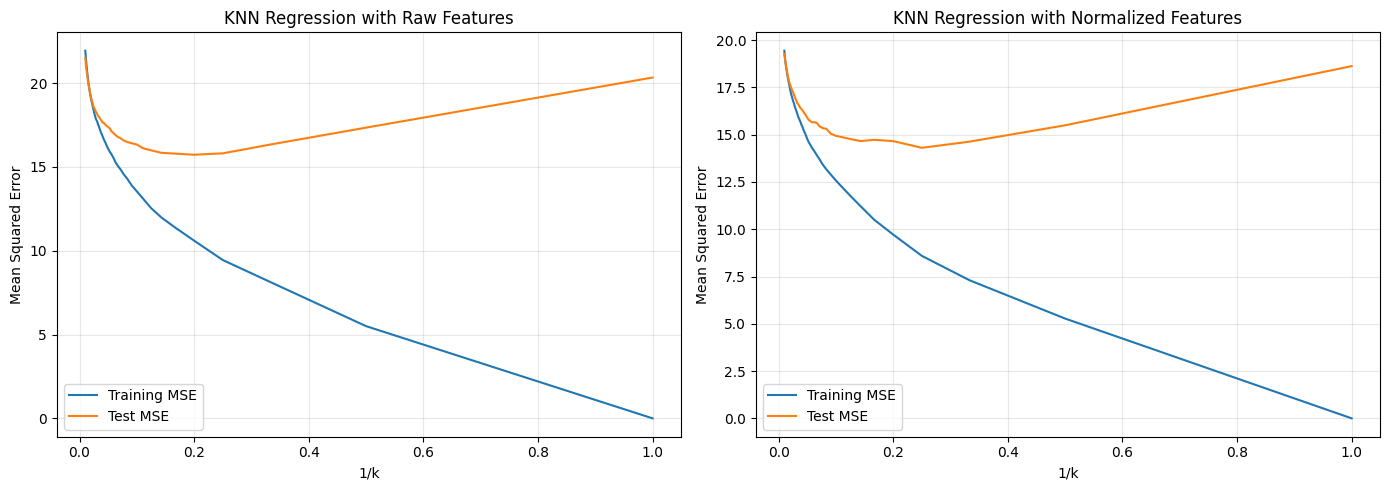

In [ ]:
inverse_k = 1 / np.array(list(k_values))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    inverse_k,
    raw_train_errors,
    label="Training MSE",
)
axes[0].plot(
    inverse_k,
    raw_test_errors,
    label="Test MSE",
)
axes[0].set_title("KNN Regression with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    inverse_k,
    normalized_train_errors,
    label="Training MSE",
)
axes[1].plot(
    inverse_k,
    normalized_test_errors,
    label="Test MSE",
)
axes[1].set_title("KNN Regression with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Answer:** I tested KNN regression with values of \(k\) from 1 to 100 using both the original predictor values and standardized predictor values. I used the same 70% training and 30% test split as in part (h).

With the raw predictors, the lowest test MSE was 15.7268 at \(k=5\). The training MSE at that value of \(k\) was 10.6008.

With the normalized predictors, the lowest test MSE was 14.3057 at \(k=4\). The training MSE at that value of \(k\) was 8.5914.

The normalized KNN model performed better because it had the lower test MSE. The plots also show the usual tradeoff: smaller values of \(k\) fit the training data more closely, while larger values of \(k\) produce smoother predictions. I selected the value of \(k\) with the lowest test MSE for each version of the data.

## 1 (j) - Comparison of KNN and Linear Regression

In [ ]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Selected Quadratic and Interaction Regression",
        "KNN with Normalized Features",
    ],
    "Training MSE": [
        enhanced_train_mse,
        normalized_train_errors[best_normalized_index],
    ],
    "Test MSE": [
        enhanced_test_mse,
        normalized_test_errors[best_normalized_index],
    ],
})

final_model_comparison

,Model,Training MSE,Test MSE
0,Selected Quadratic and Interaction Regression,17.890843,18.660040
1,KNN with Normalized Features,8.591433,14.305669


**Answer:** Of the regression models from part (h), the model with selected quadratic and interaction terms had the lowest test MSE. Its training MSE was 17.8908, and its test MSE was 18.6600.

The best KNN model used normalized predictors with \(k=4\). It had a training MSE of 8.5914 and a test MSE of 14.3057. This is about a 23.3% lower test MSE than the best regression model.

Based on test MSE, the normalized KNN model was the best model tested. It likely performs better because it can capture relationships that are not fully described by the regression model's linear, quadratic, and interaction terms.

Normalization was important for KNN because it is based on the distance between observations. Scaling the predictors puts them on a similar range so variables with larger values do not have too much influence on the distance calculation.

## (2) - ISLR: 2.4.1
### Question
1. For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

- (a) The sample size n is extremely large, and the number of predictors p is small.
- (b) The number of predictors p is extremely large, and the number of observations n is small.
- (c) The relationship between the predictors and response is highly non-linear.
- (d) The variance of the error terms, i.e. σ2 = Var("), is extremely high.

### Answer

**(a) Better.** A flexible method would likely perform better because there are many observations and only a small number of predictors. With a large sample size, the model has enough data to estimate a more complex relationship without overfitting as easily.

**(b) Worse.** A flexible method would likely perform worse because there are many predictors but only a small number of observations. A more flexible model could fit noise in the training data and may not perform well on new data. A less flexible method would be less likely to overfit.

**(c) Better.** A flexible method would likely perform better because it can model a nonlinear relationship between the predictors and the response. A less flexible method may be too simple and miss important patterns in the data.

**(d) Worse.** A flexible method would likely perform worse when the error variance is very high. It may fit random noise instead of the actual pattern in the data. A less flexible method is less likely to overfit the noise, although neither method can reduce the irreducible error.

## (3) - ISLR: 2.4.7
### Question
7. The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | \(X_1\) | \(X_2\) | \(X_3\) | \(Y\) |
|-----:|--------:|--------:|--------:|:------|
| 1 | 0  | 3 | 0 | Red   |
| 2 | 2  | 0 | 0 | Red   |
| 3 | 0  | 1 | 3 | Red   |
| 4 | 0  | 1 | 2 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1  | 1 | 1 | Red   |

Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

- (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.
- (b) What is our prediction with K = 1? Why?
- (c) What is our prediction with K = 3? Why?
- (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

### Answer

**(a)** The Euclidean distance from each observation to the test point \((0,0,0)\) is:

\[
d = \sqrt{X_1^2 + X_2^2 + X_3^2}
\]

| Observation | Distance | Approximate Distance | \(Y\) |
|---:|:---|---:|:---|
| 1 | \(\sqrt{0^2 + 3^2 + 0^2} = 3\) | 3.000 | Red |
| 2 | \(\sqrt{2^2 + 0^2 + 0^2} = 2\) | 2.000 | Red |
| 3 | \(\sqrt{0^2 + 1^2 + 3^2} = \sqrt{10}\) | 3.162 | Red |
| 4 | \(\sqrt{0^2 + 1^2 + 2^2} = \sqrt{5}\) | 2.236 | Green |
| 5 | \(\sqrt{(-1)^2 + 0^2 + 1^2} = \sqrt{2}\) | 1.414 | Green |
| 6 | \(\sqrt{1^2 + 1^2 + 1^2} = \sqrt{3}\) | 1.732 | Red |

**(b)** With \(K=1\), the prediction is **Green**. Observation 5 is closest to the test point, and its class is Green.

**(c)** With \(K=3\), the prediction is **Red**. The three closest observations are 5, 6, and 2. Their classes are Green, Red, and Red, so Red gets two of the three votes.

**(d)** The best value of \(K\) would likely be small. A smaller \(K\) gives KNN a more flexible decision boundary, which is useful when the true Bayes decision boundary is highly nonlinear. A larger \(K\) creates a smoother boundary and could miss smaller local patterns.